# Heteroscedastic Multi-Output Deep Ensemble for 2D Transport

This notebook uses `HeteroscedasticMultiOutputDeepEnsembleRegressor` on a
2D advection-diffusion transport problem. The ensemble predicts both final
concentration and flux magnitude, together with per-pixel aleatoric noise.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'sciml':
    PROJECT = ROOT.parents[1]
else:
    PROJECT = ROOT
SRC = PROJECT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import math
import random

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import HeteroscedasticMultiOutputDeepEnsembleRegressor
from deepuq.models import CNNRegressor2D

torch.manual_seed(21)
random.seed(21)

## Physical problem

We evolve a concentration field under periodic 2D advection-diffusion:

$$
\partial_t c + v_x \partial_x c + v_y \partial_y c = D \Delta c.
$$

The two outputs are:
- final concentration $c(x, y, T)$,
- flux magnitude $\|\mathbf{J}(x, y, T)\|$.

Observation noise is stronger where concentration is larger, which gives a
scientifically meaningful heteroscedastic target.

In [3]:
def sample_initial_field(n, size, *, ood=False):
    grid = torch.linspace(0.0, 1.0, size + 1)[:-1]
    X, Y = torch.meshgrid(grid, grid, indexing='ij')
    fields = []
    for _ in range(n):
        field = torch.zeros_like(X)
        low = 4 if ood else 1
        high = 6 if ood else 3
        for kx in range(low, high + 1):
            for ky in range(low, high + 1):
                coeff = random.uniform(-1.0, 1.0) / (kx + ky)
                phase = random.uniform(0.0, 2.0 * math.pi)
                field = field + coeff * torch.sin(2.0 * math.pi * (kx * X + ky * Y) + phase)
        fields.append(field)
    return torch.stack(fields, dim=0)

def evolve_transport(c0, vx=0.4, vy=-0.2, diff=0.01, T=0.08):
    size = c0.shape[-1]
    freqs = torch.fft.fftfreq(size, d=1.0 / size)
    KX, KY = torch.meshgrid(freqs, freqs, indexing='ij')
    ksq = KX**2 + KY**2
    c_hat0 = torch.fft.fftn(c0, dim=(-2, -1))
    phase = torch.exp((-4.0 * math.pi**2 * diff * ksq - 2j * math.pi * (vx * KX + vy * KY)) * T)
    cT = torch.fft.ifftn(c_hat0 * phase, dim=(-2, -1)).real
    grad_x = torch.gradient(cT, dim=-2)[0] * size
    grad_y = torch.gradient(cT, dim=-1)[0] * size
    flux_mag = torch.sqrt((vx * cT - diff * grad_x) ** 2 + (vy * cT - diff * grad_y) ** 2 + 1e-8)
    return cT, flux_mag

def make_dataset(n, size=24, *, ood=False):
    c0 = sample_initial_field(n, size, ood=ood)
    cT, flux = evolve_transport(c0)
    noise_scale = 0.01 + 0.05 * cT.abs()
    noisy_targets = torch.stack([
        cT + noise_scale * torch.randn_like(cT),
        flux + 0.5 * noise_scale * torch.randn_like(flux),
    ], dim=1)
    return c0.unsqueeze(1), noisy_targets, torch.stack([cT, flux], dim=1)

In [4]:
train_x, train_y, _ = make_dataset(96)
test_x, _, test_clean = make_dataset(24)
ood_x, _, ood_clean = make_dataset(24, ood=True)
loader = DataLoader(TensorDataset(train_x, train_y), batch_size=8, shuffle=True)
models = [CNNRegressor2D(in_channels=1, out_channels=4, hidden_channels=(16, 24, 24, 24), dropout_p=0.0) for _ in range(3)]
ensemble = HeteroscedasticMultiOutputDeepEnsembleRegressor(models)
ensemble.fit(loader, epochs=40, lr=1e-3, seed=44)

HeteroscedasticMultiOutputDeepEnsembleRegressor(
  (models): ModuleList(
    (0-2): 3 x CNNRegressor2D(
      (backbone): Sequential(
        (0): _ConvBlock2D(
          (net): Sequential(
            (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): GELU(approximate='none')
            (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (3): GELU(approximate='none')
          )
        )
        (1): _ConvBlock2D(
          (net): Sequential(
            (0): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): GELU(approximate='none')
            (2): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (3): GELU(approximate='none')
          )
        )
        (2): _ConvBlock2D(
          (net): Sequential(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): GELU(approximate='none')
            (2): Conv2d(24, 24

test mean std 0.05353245884180069
ood mean std 0.04260021820664406


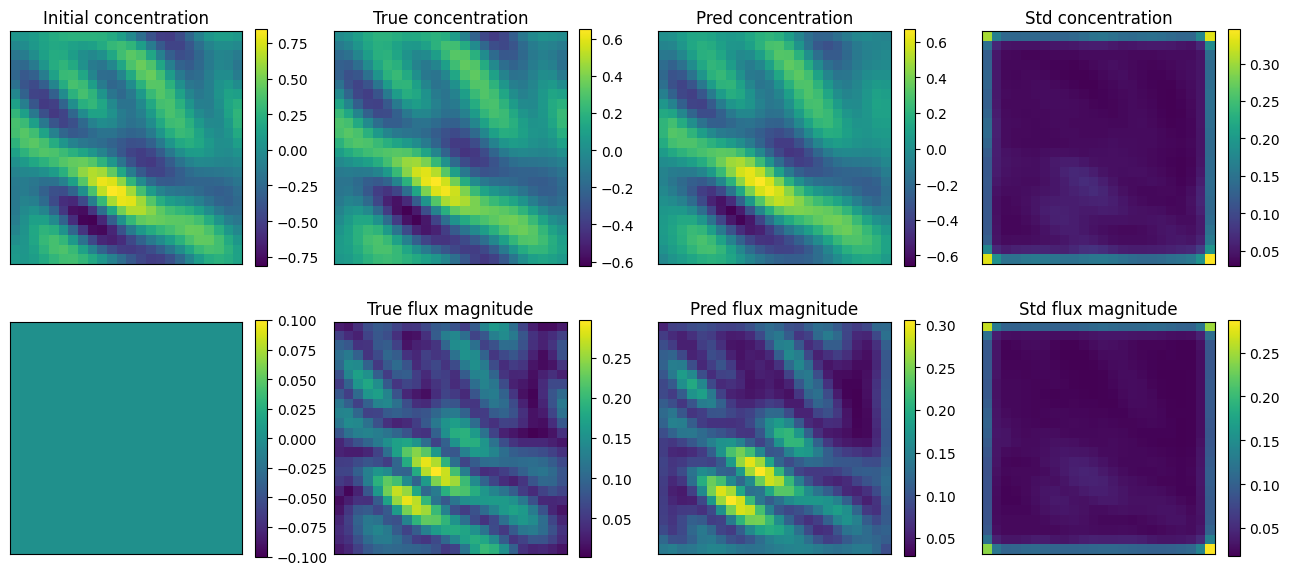

In [5]:
uq_test = ensemble.predict_uq(test_x)
uq_ood = ensemble.predict_uq(ood_x)
print('test mean std', uq_test.total_var.sqrt().mean().item())
print('ood mean std', uq_ood.total_var.sqrt().mean().item())

idx = 0
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
panels = [
    (test_x[idx, 0], 'Initial concentration'),
    (test_clean[idx, 0], 'True concentration'),
    (uq_test.mean[idx, 0], 'Pred concentration'),
    (uq_test.total_var[idx, 0].sqrt(), 'Std concentration'),
    (torch.zeros_like(test_x[idx, 0]), ''),
    (test_clean[idx, 1], 'True flux magnitude'),
    (uq_test.mean[idx, 1], 'Pred flux magnitude'),
    (uq_test.total_var[idx, 1].sqrt(), 'Std flux magnitude'),
]
for ax, (arr, title) in zip(axes.flat, panels):
    im = ax.imshow(arr.detach().numpy(), origin='lower', cmap='viridis')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()